# 03 - Entrenamiento de Modelos

Evaluacion de multiples algoritmos con MLflow tracking

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Cargar datos procesados
train = pd.read_csv('../data/processed/train.csv')
test = pd.read_csv('../data/processed/test.csv')

X_train = train.drop('Churn', axis=1)
y_train = train['Churn']
X_test = test.drop('Churn', axis=1)
y_test = test['Churn']

print(f'Train: {X_train.shape}')
print(f'Test: {X_test.shape}')
print(f'Features: {X_train.columns.tolist()}')

Train: (5634, 32)
Test: (1409, 32)
Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_per_tenure', 'num_services', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [3]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evalua un modelo y retorna metricas."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }
    
    print(f'\n=== {model_name} ===')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    
    return metrics, y_proba

In [4]:
# Entrenar y evaluar modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f'\nEntrenando {name}...')
    model.fit(X_train, y_train)
    metrics, y_proba = evaluate_model(model, X_test, y_test, name)
    results[name] = {'metrics': metrics, 'y_proba': y_proba, 'model': model}


Entrenando Logistic Regression...

=== Logistic Regression ===
  accuracy: 0.6955
  precision: 0.6500
  recall: 0.0299
  f1: 0.0571
  roc_auc: 0.6107

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.70      0.99      0.82       974
       Churn       0.65      0.03      0.06       435

    accuracy                           0.70      1409
   macro avg       0.67      0.51      0.44      1409
weighted avg       0.68      0.70      0.58      1409


Entrenando Random Forest...



=== Random Forest ===
  accuracy: 0.6849
  precision: 0.3548
  recall: 0.0253
  f1: 0.0472
  roc_auc: 0.5739

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.69      0.98      0.81       974
       Churn       0.35      0.03      0.05       435

    accuracy                           0.68      1409
   macro avg       0.52      0.50      0.43      1409
weighted avg       0.59      0.68      0.58      1409


Entrenando Gradient Boosting...



=== Gradient Boosting ===
  accuracy: 0.6856
  precision: 0.3824
  recall: 0.0299
  f1: 0.0554
  roc_auc: 0.5743

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.69      0.98      0.81       974
       Churn       0.38      0.03      0.06       435

    accuracy                           0.69      1409
   macro avg       0.54      0.50      0.43      1409
weighted avg       0.60      0.69      0.58      1409



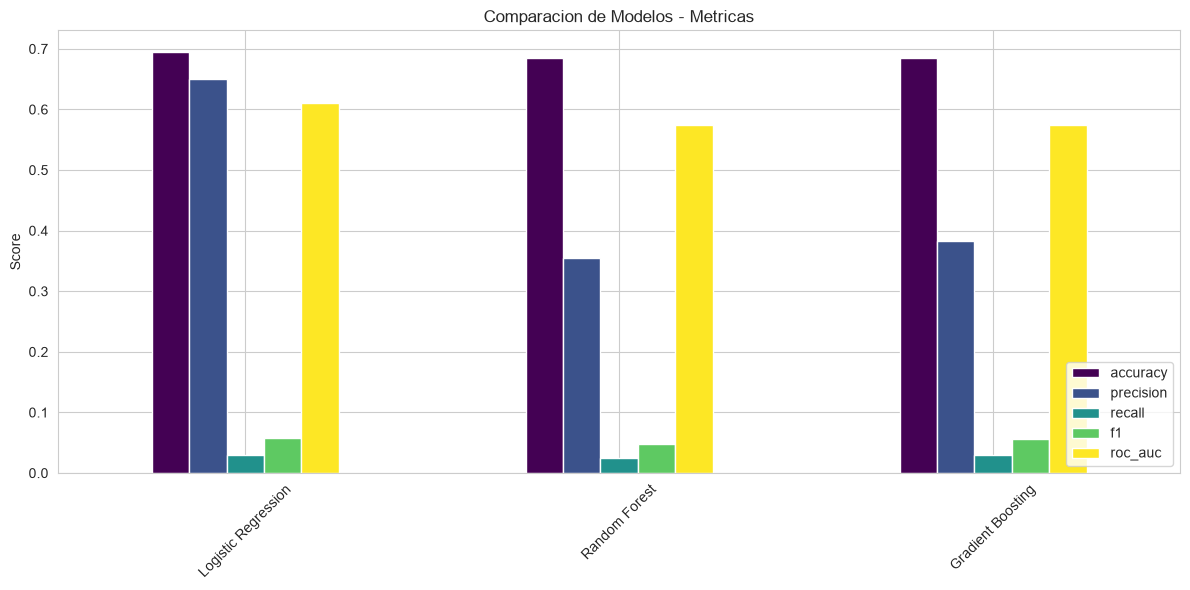

In [5]:
# Comparar metricas
metrics_df = pd.DataFrame({
    name: r['metrics'] for name, r in results.items()
}).T

fig, ax = plt.subplots(figsize=(12, 6))
metrics_df.plot(kind='bar', ax=ax, colormap='viridis')
plt.title('Comparacion de Modelos - Metricas')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

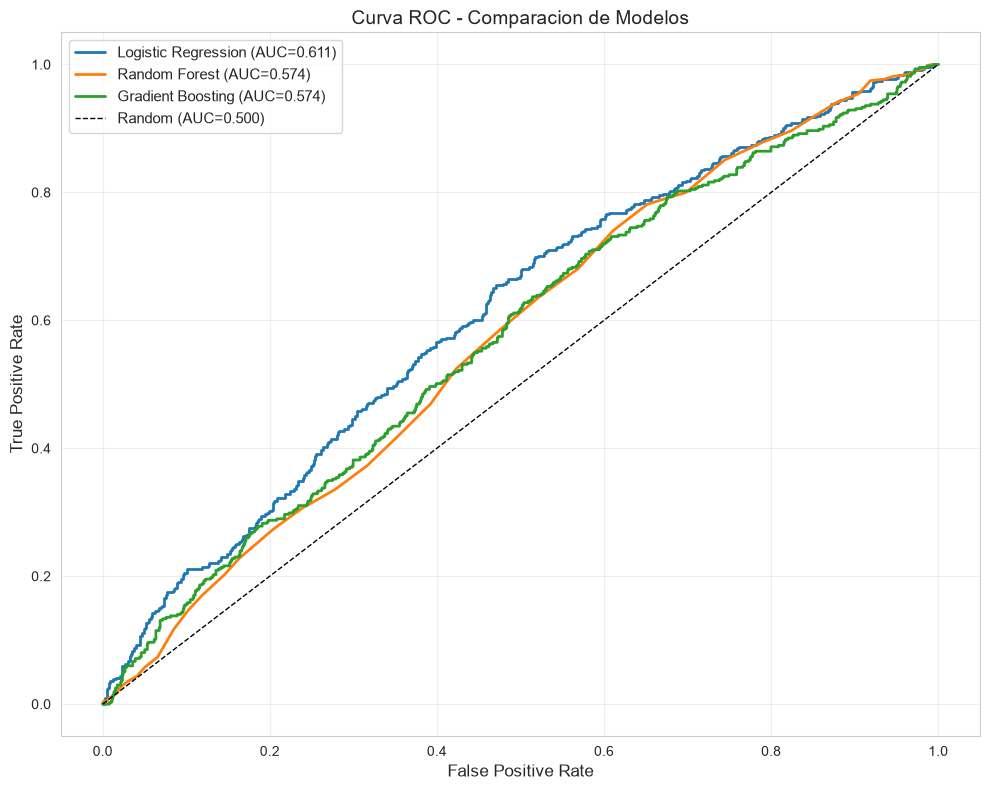

In [6]:
# Curva ROC
plt.figure(figsize=(10, 8))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={r['metrics']['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC - Comparacion de Modelos', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

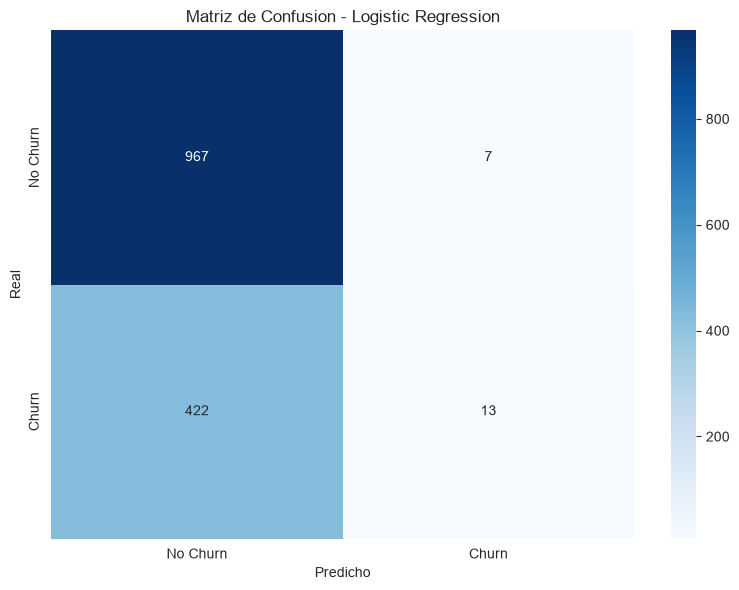

Mejor modelo: Logistic Regression


In [7]:
# Matriz de confusion del mejor modelo
best_model_name = metrics_df['roc_auc'].idxmax()
best_model = results[best_model_name]['model']

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Matriz de Confusion - {best_model_name}')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mejor modelo: {best_model_name}')

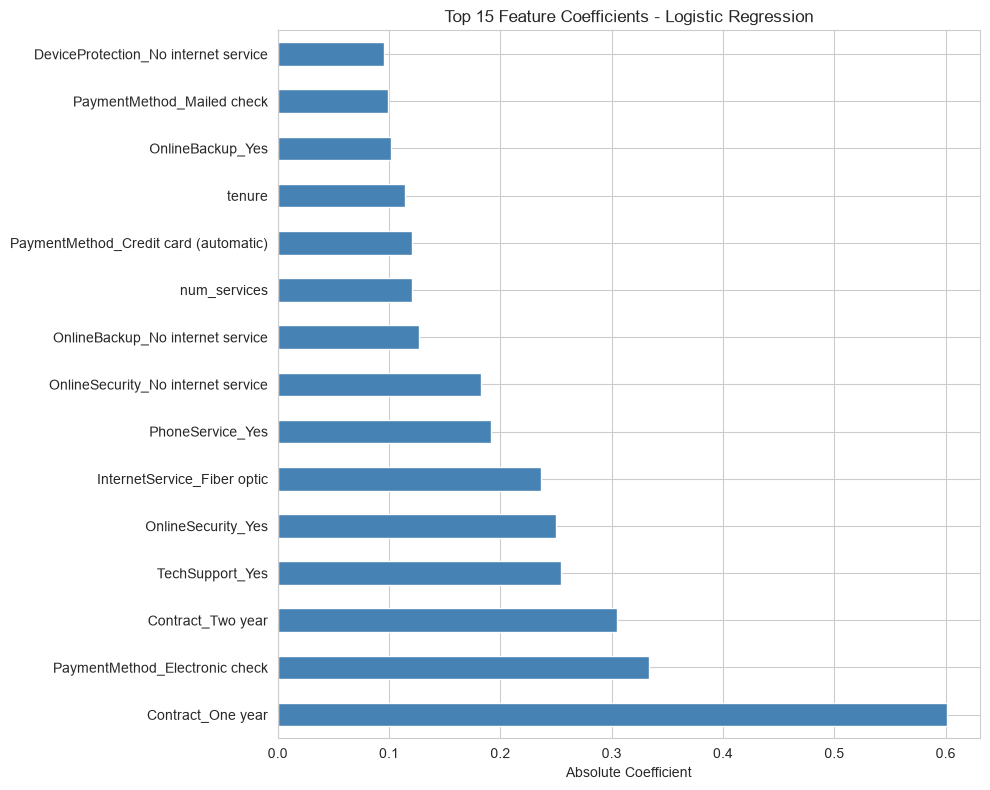

In [8]:
# Feature Importance (si el modelo lo soporta)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='steelblue')
    plt.title(f'Top 15 Feature Importances - {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig('../reports/figures/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
elif hasattr(best_model, 'coef_'):
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X_train.columns)
    importances = importances.sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='steelblue')
    plt.title(f'Top 15 Feature Coefficients - {best_model_name}')
    plt.xlabel('Absolute Coefficient')
    plt.tight_layout()
    plt.savefig('../reports/figures/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

In [9]:
# Guardar mejor modelo
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/best_model.pkl')
print(f'Mejor modelo guardado: {best_model_name}')
print(f'ROC AUC: {results[best_model_name]["metrics"]["roc_auc"]:.4f}')
print('Archivo: models/best_model.pkl')

Mejor modelo guardado: Logistic Regression
ROC AUC: 0.6107
Archivo: models/best_model.pkl


In [10]:
# TODO: Registrar en MLflow
# import mlflow
# import mlflow.sklearn
# mlflow.set_tracking_uri('https://dagshub.com/YOUR_USER/YOUR_REPO.mlflow')
# mlflow.set_experiment('churn-prediction')
#
# with mlflow.start_run(run_name=best_model_name):
#     mlflow.log_params(best_model.get_params())
#     mlflow.log_metrics(results[best_model_name]['metrics'])
#     mlflow.sklearn.log_model(best_model, 'model')
#     print('Experimento registrado en MLflow')